#### Import Python packages

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model, save_model
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import cross_validate

### Import Phishing Detection Dataset: https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset/data

In [40]:
data = pd.read_csv('../raw_data/dataset_phishing.csv')
data.head(10)

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
5,http://appleid.apple.com-app.es/,32,24,0,3,1,0,0,0,0,...,1,1,1,0,-1,0,0,1,0,phishing
6,http://www.mutuo.it,19,12,0,2,0,0,0,0,0,...,0,1,0,170,7529,0,0,0,1,legitimate
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
8,http://vamoaestudiarmedicina.blogspot.com/,42,34,0,2,0,0,0,0,0,...,1,1,0,371,7298,0,0,0,5,legitimate
9,https://parade.com/425836/joshwigler/the-amazi...,104,10,0,1,10,0,0,0,0,...,1,0,0,128,9368,6774,0,0,5,legitimate


### Assess if the class frequencies are balanced 

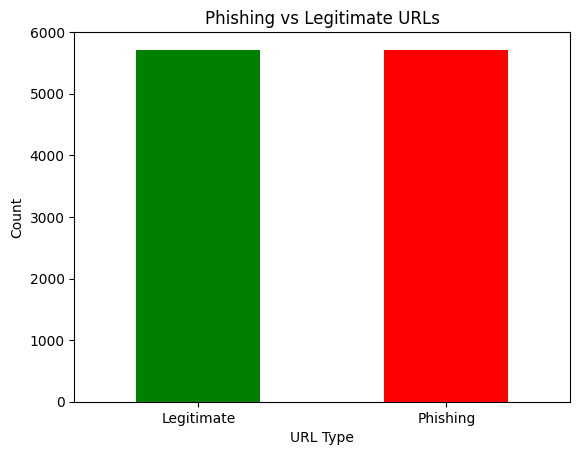

In [41]:
counts = data["status"].value_counts()

ax = counts.plot(kind="bar", color=["green", "red"], rot=0)

plt.title("Phishing vs Legitimate URLs")
plt.xlabel("URL Type")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Legitimate", "Phishing"])
plt.show()

## Dataset preprocessing

### Remove records with missing values

In [42]:
data.dropna(inplace=True)

### Remove corrupted records with invalid "domain_age" values

In [43]:
data.drop(data[data['domain_age'] <= -1].index, inplace=True)

### Target mapping

In [44]:
# Encoding 'status' column (target) as 1 for phishing and 0 for legitimate urls

class_map = {'legitimate':0, 'phishing':1}
data['status'] = data['status'].map(class_map)

### Features Correlation Inspection

<Axes: >

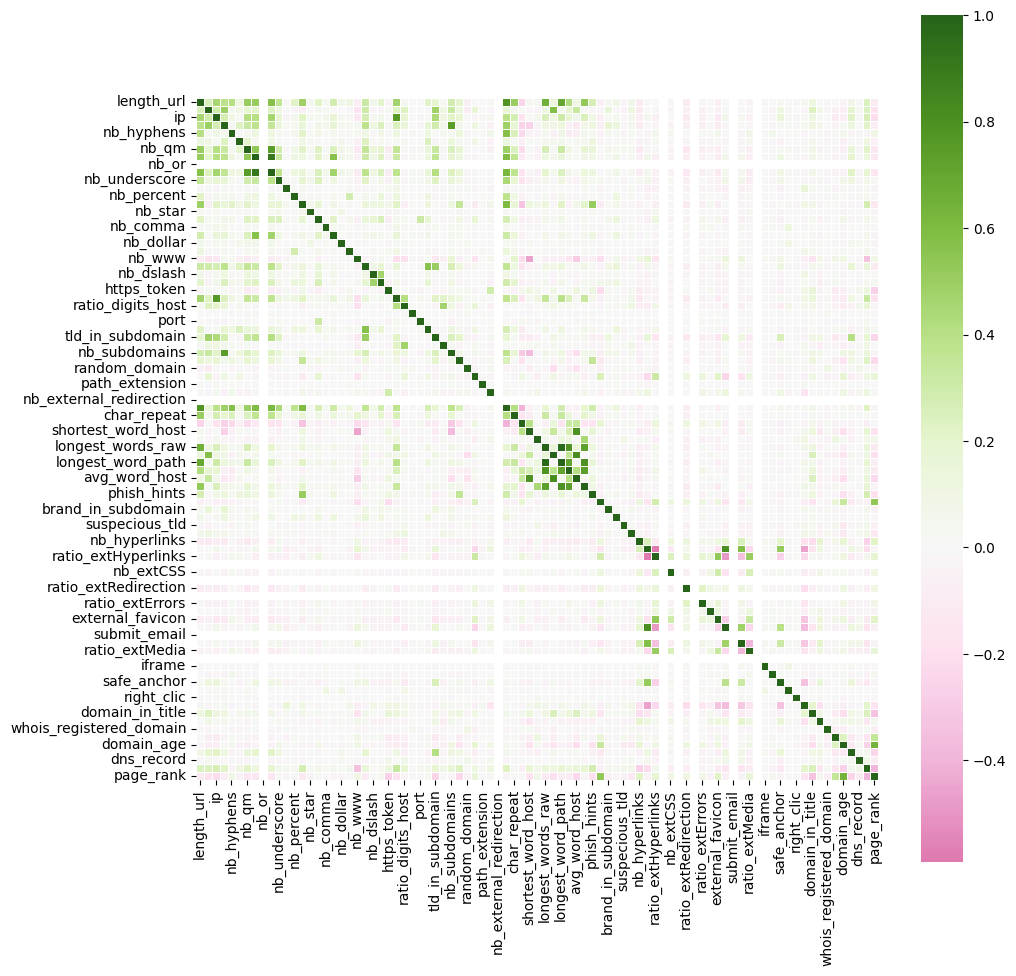

In [45]:
corr = data.drop(columns=["url", "status"]).corr()

fig = plt.figure(figsize=(11,11),dpi=100)
sns.heatmap(corr, center=0, cmap="PiYG", square=True, linewidths=.5)

#### Check for **Multicollinearity**
Correlation between features helps you identify ***multicollinearity***- when two features carry the same information. Here's how to think about it:<br>
**High pair correlation + both correlated with target** → Keep only one of them. They're redundant - the model doesn't gain new information from having both.

In [46]:
# Get full correlation matrix
corr = data.drop(columns=["url", "status"]).corr()
target_corr = data.drop(columns=["url"]).corr()["status"].drop("status")

# Get all unique pairs from upper triangle
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
all_pairs = upper.stack().reset_index()
all_pairs.columns = ["feature_1", "feature_2", "pair_correlation"]

# Map target correlations
all_pairs["feature_1_vs_target"] = all_pairs["feature_1"].map(target_corr)
all_pairs["feature_2_vs_target"] = all_pairs["feature_2"].map(target_corr)

# Flag which feature to drop from each redundant pair
threshold = 0.75

redundant = all_pairs[all_pairs["pair_correlation"].abs() > threshold].copy()
redundant["drop"] = redundant.apply(
    lambda r: r["feature_1"] if abs(r["feature_1_vs_target"]) < abs(r["feature_2_vs_target"])
              else r["feature_2"], axis=1
)

# Get final unique set of features to drop
features_to_drop = set(redundant["drop"].tolist())
for feature in features_to_drop:
    print(f"DROP: '{feature}'")
    
    # All pairs where this feature was flagged to drop
    evidence = redundant[redundant["drop"] == feature]
    
    for _, row in evidence.iterrows():
        kept = row["feature_2"] if row["drop"] == row["feature_1"] else row["feature_1"]
        kept_target = row["feature_2_vs_target"] if row["drop"] == row["feature_1"] else row["feature_1_vs_target"]
        drop_target = row["feature_1_vs_target"] if row["drop"] == row["feature_1"] else row["feature_2_vs_target"]
        
        print(f"-- Pair correlation with '{kept}': {row['pair_correlation']:.4f}")
        print(f"-- '{feature}' vs target:          {drop_target:.4f}")
        print(f"-- '{kept}' vs target:             {kept_target:.4f}  ← kept")
    print()

# Clean dataset
data_filtered = data.drop(columns=list(features_to_drop))
all_drops = features_to_drop
print(f"Remaining features: {data_filtered.shape[1]}")

DROP: 'longest_word_host'
-- Pair correlation with 'avg_word_host': 0.8172
-- 'longest_word_host' vs target:          0.1503
-- 'avg_word_host' vs target:             0.2137  ← kept

DROP: 'nb_and'
-- Pair correlation with 'nb_eq': 0.9029
-- 'nb_and' vs target:          0.1816
-- 'nb_eq' vs target:             0.2489  ← kept

DROP: 'avg_words_raw'
-- Pair correlation with 'longest_words_raw': 0.7931
-- 'avg_words_raw' vs target:          0.1840
-- 'longest_words_raw' vs target:             0.2025  ← kept

DROP: 'links_in_tags'
-- Pair correlation with 'ratio_intHyperlinks': 0.8047
-- 'links_in_tags' vs target:          -0.1904
-- 'ratio_intHyperlinks' vs target:             -0.2584  ← kept

DROP: 'ip'
-- Pair correlation with 'ratio_digits_url': 0.7588
-- 'ip' vs target:          0.3127
-- 'ratio_digits_url' vs target:             0.3532  ← kept

DROP: 'length_words_raw'
-- Pair correlation with 'length_url': 0.7821
-- 'length_words_raw' vs target:          0.1763
-- 'length_url' vs ta

#### Variance Threshold
Features with very low variance are nearly constant across all rows, meaning they carry almost no information for the model.

In [47]:
X = data.drop(columns=["url", "status"])
y = data["status"]

selector = VarianceThreshold(threshold=0.005)  # features with var < 0.01 are flagged
selector.fit(X)

# get_support() returns True for features that PASS the threshold
# we invert it (~) to get the features that FAIL (low variance)
low_variance_features = X.columns[~selector.get_support()].tolist()

for feature in low_variance_features:
    print(f"DROP: '{feature}' - variance: {X[feature].var():.6f}  (below threshold of 0.01)'")
    all_drops.add(feature)

DROP: 'nb_or' - variance: 0.000000  (below threshold of 0.01)'
DROP: 'nb_star' - variance: 0.000833  (below threshold of 0.01)'
DROP: 'ratio_digits_host' - variance: 0.004143  (below threshold of 0.01)'
DROP: 'punycode' - variance: 0.000208  (below threshold of 0.01)'
DROP: 'port' - variance: 0.002288  (below threshold of 0.01)'
DROP: 'path_extension' - variance: 0.000208  (below threshold of 0.01)'
DROP: 'nb_external_redirection' - variance: 0.000000  (below threshold of 0.01)'
DROP: 'brand_in_subdomain' - variance: 0.003843  (below threshold of 0.01)'
DROP: 'brand_in_path' - variance: 0.003221  (below threshold of 0.01)'
DROP: 'ratio_nullHyperlinks' - variance: 0.000000  (below threshold of 0.01)'
DROP: 'ratio_intRedirection' - variance: 0.000000  (below threshold of 0.01)'
DROP: 'ratio_intErrors' - variance: 0.000000  (below threshold of 0.01)'
DROP: 'submit_email' - variance: 0.000000  (below threshold of 0.01)'
DROP: 'sfh' - variance: 0.000000  (below threshold of 0.01)'
DROP: 'if

#### Features Correlation with Target
A feature that has little to no linear correlation with the target variable is unlikely to help the model distinguish between phishing and legitimate URLs.<br>
***NOTE: this only captures linear relationships - a feature with low correlation could still be useful if its relationship with the target is non-linear.***

In [48]:
target_corr = data.drop(columns=["url"]).corr()["status"].drop("status")
threshold_target = 0.023  # features with |correlation| < 0.05 are considered weak

for feature, corr_val in target_corr.abs().sort_values(ascending=False).items():
    if corr_val < threshold_target:
        print(f"DROP: '{feature}' - correlation with target: {corr_val:.4f}")
        all_drops.add(feature)

weak_features = target_corr[target_corr.abs() < threshold_target].index.tolist()

DROP: 'login_form' - correlation with target: 0.0210
DROP: 'shortest_words_raw' - correlation with target: 0.0156
DROP: 'char_repeat' - correlation with target: 0.0154
DROP: 'punycode' - correlation with target: 0.0147
DROP: 'nb_comma' - correlation with target: 0.0146
DROP: 'iframe' - correlation with target: 0.0136
DROP: 'right_clic' - correlation with target: 0.0091
DROP: 'nb_space' - correlation with target: 0.0059
DROP: 'random_domain' - correlation with target: 0.0030
DROP: 'onmouseover' - correlation with target: 0.0029
DROP: 'port' - correlation with target: 0.0008
DROP: 'path_extension' - correlation with target: 0.0002


#### Random Forest Feature Importance
*Random Forest* measures how much each feature reduces impurity (uncertainty) across all decision trees in the forest.<br>
Unlike correlation, this captures **non-linear relationships** and interactions between features.

In [49]:
rf = RandomForestClassifier(
    n_estimators=100,   # number of trees — more trees = more stable importance scores
    random_state=42     # fixed seed for reproducibility
)
rf.fit(X, y)

# feature_importances_ gives a score for each feature that sums to 1.0
# higher score = more useful for distinguishing phishing vs legitimate
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

threshold_importance = 0.005  # features contributing less than 0.5% are flagged

for feature, imp in importances.items():
    if imp < threshold_importance:
        print(f"DROP: '{feature}' - importance score: {imp:.4f}")
        all_drops.add(feature)

low_importance_features = importances[importances < threshold_importance].index.tolist()

DROP: 'domain_with_copyright' - importance score: 0.0048
DROP: 'ratio_extMedia' - importance score: 0.0047
DROP: 'ratio_intMedia' - importance score: 0.0044
DROP: 'nb_extCSS' - importance score: 0.0039
DROP: 'domain_in_brand' - importance score: 0.0038
DROP: 'nb_redirection' - importance score: 0.0037
DROP: 'nb_subdomains' - importance score: 0.0035
DROP: 'prefix_suffix' - importance score: 0.0029
DROP: 'shortening_service' - importance score: 0.0027
DROP: 'dns_record' - importance score: 0.0026
DROP: 'nb_underscore' - importance score: 0.0024
DROP: 'https_token' - importance score: 0.0021
DROP: 'empty_title' - importance score: 0.0018
DROP: 'nb_percent' - importance score: 0.0016
DROP: 'nb_com' - importance score: 0.0015
DROP: 'external_favicon' - importance score: 0.0015
DROP: 'nb_and' - importance score: 0.0013
DROP: 'nb_space' - importance score: 0.0012
DROP: 'http_in_path' - importance score: 0.0010
DROP: 'login_form' - importance score: 0.0009
DROP: 'suspecious_tld' - importance 

#### **Feature Screening Summary**

In [50]:
print(f"Low variance features:         {len(low_variance_features)}")
print(f"Weak target correlation:       {len(weak_features)}")
print(f"Low RF importance:             {len(low_importance_features)}")
print(f"Total unique features to drop: {len(all_drops)}")
print(f"\nFeatures dropped: \n{all_drops}")

data_filtered = data.drop(columns=list(all_drops))
print(f"\nOriginal feature count:  {X.shape[1]}")
print(f"Remaining feature count: {data_filtered.shape[1] - 2}")

Low variance features:         17
Weak target correlation:       12
Low RF importance:             51
Total unique features to drop: 62

Features dropped: 
{'shortening_service', 'domain_in_brand', 'port', 'https_token', 'nb_com', 'login_form', 'ip', 'external_favicon', 'punycode', 'nb_redirection', 'nb_tilde', 'avg_word_host', 'iframe', 'nb_percent', 'longest_word_host', 'prefix_suffix', 'submit_email', 'abnormal_subdomain', 'http_in_path', 'ratio_intRedirection', 'nb_underscore', 'ratio_intMedia', 'nb_at', 'path_extension', 'brand_in_subdomain', 'onmouseover', 'domain_with_copyright', 'empty_title', 'statistical_report', 'sfh', 'nb_dslash', 'avg_words_raw', 'whois_registered_domain', 'ratio_intErrors', 'ratio_extMedia', 'nb_space', 'nb_or', 'longest_words_raw', 'ratio_digits_host', 'right_clic', 'nb_star', 'nb_semicolumn', 'brand_in_path', 'popup_window', 'nb_dollar', 'tld_in_subdomain', 'nb_external_redirection', 'nb_extCSS', 'nb_colon', 'nb_and', 'ratio_nullHyperlinks', 'links_in_t

In [51]:
data_filtered.columns

Index(['url', 'length_url', 'length_hostname', 'nb_dots', 'nb_hyphens',
       'nb_qm', 'nb_eq', 'nb_slash', 'nb_www', 'ratio_digits_url',
       'shortest_word_host', 'shortest_word_path', 'longest_word_path',
       'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks',
       'ratio_extHyperlinks', 'ratio_extRedirection', 'ratio_extErrors',
       'safe_anchor', 'domain_in_title', 'domain_registration_length',
       'domain_age', 'web_traffic', 'google_index', 'page_rank', 'status'],
      dtype='str')

### Feature normalization
Scaling feature values to a common range so that no single feature dominates the model due to its magnitude.

In [52]:
X_filtered = data_filtered.drop(columns=["url", "status"])
X_filtered = X_filtered.drop(columns=["web_traffic", "google_index", "page_rank"]) # cannot be extracted without external APIs
y = data_filtered["status"]

scaler = MinMaxScaler() # squishes values to a [0, 1] range
X_scaled = pd.DataFrame(scaler.fit_transform(X_filtered), columns=X_filtered.columns)

In [53]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [54]:
X_scaled.head()

,length_url,length_hostname,nb_dots,nb_hyphens,nb_qm,nb_eq,nb_slash,nb_www,ratio_digits_url,shortest_word_host,...,phish_hints,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_extRedirection,ratio_extErrors,safe_anchor,domain_in_title,domain_registration_length,domain_age
0,0.039312,0.081731,0.000000,0.000000,0.000000,0.000000,0.096774,0.0,0.304994,0.473684,...,0.0,0.006439,0.966667,0.033333,0.000000,0.000000,1.0,1.0,0.002615,0.447957
1,0.069410,0.211538,0.142857,0.023256,0.333333,0.176471,0.096774,0.0,0.208313,0.052632,...,0.0,0.000859,1.000000,0.000000,0.000000,0.000000,1.0,1.0,0.000503,0.311014
2,0.025799,0.043269,0.047619,0.046512,0.000000,0.000000,0.096774,0.5,0.000000,0.052632,...,0.0,0.021893,0.470588,0.529412,0.268519,0.018519,0.0,0.0,0.007543,0.635001
3,0.003686,0.028846,0.047619,0.000000,0.000000,0.000000,0.000000,0.5,0.000000,0.052632,...,0.0,0.021035,0.081633,0.918367,0.000000,0.000000,1.0,0.0,0.005732,0.584822
4,0.041769,0.100962,0.047619,0.000000,0.000000,0.000000,0.096774,0.5,0.358152,0.052632,...,0.0,0.006439,0.966667,0.033333,0.000000,0.000000,1.0,1.0,0.002581,0.447957


## Model Design and Evaluation

**K-Nearest Neighbours (KNN)** is a non-parametric, instance-based algorithm that classifies observations based on the majority class among their K nearest neighbours in feature space. 

**Logistic Regression** is a parametric classifier that estimates class membership probability via a linear combination of input features.

### Model Optimization

In [55]:
# We split data before any optimization to ensure the test set is never seen
# during training or tuning - this gives an honest estimate of real-world performance.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    stratify=y          # preserve class balance in both splits
)

**GridSearchCV** tries every combination of *hyperparameters* using **cross-validation** (splits training data into 5 folds, trains on 4, validates on 1, rotates).<br>
This finds the best settings WITHOUT touching the test set.

#### KNN Optimization

In [56]:
knn_param_grid = {
    "n_neighbors": [3, 4, 5, 6, 7, 8, 9, 10, 11],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,           # 5-fold cross validation
    scoring="accuracy",
    n_jobs=-1,      # use all CPU cores to speed up search
    verbose=1
)
knn_grid.fit(X_train, y_train)

print(f"Best parameters : {knn_grid.best_params_}")
print(f"Best CV accuracy: {knn_grid.best_score_:.4f}\n")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters : {'metric': 'manhattan', 'n_neighbors': 3}
Best CV accuracy: 0.9163



#### Logistic Regression Optimization

In [57]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print(f"Best parameters : {lr_grid.best_params_}")
print(f"Best CV accuracy: {lr_grid.best_score_:.4f}\n")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters : {'C': 100, 'solver': 'lbfgs'}
Best CV accuracy: 0.8963



### Model Training

In [58]:
def train_and_evaluate(name, model, X_train, X_test, y_train, y_test):
    # Train on full training set using best hyperparameters
    model.fit(X_train, y_train)
    
    # Predict on unseen test set
    y_pred = model.predict(X_test)
    
    # Cross-validation on training set to check for overfitting
    # If CV score >> test score, the model is likely overfitting
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    
    print(f"{name} Results")
    print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"CV Accuracy   : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()
    
    return {
        "model": name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "cv_accuracy": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

#### KNN

In [59]:
results_knn = train_and_evaluate(
    "KNN",
    knn_grid.best_estimator_,
    X_train, X_test, y_train, y_test
)

KNN Results
Test Accuracy : 0.9265
CV Accuracy   : 0.9163 (+/- 0.0067)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.91      0.94      0.93       975
    Phishing       0.94      0.91      0.92       944

    accuracy                           0.93      1919
   macro avg       0.93      0.93      0.93      1919
weighted avg       0.93      0.93      0.93      1919

Confusion Matrix:
[[920  55]
 [ 86 858]]



#### Logistic Regression

In [60]:
results_lr = train_and_evaluate(
    "Logistic Regression",
    lr_grid.best_estimator_,
    X_train, X_test, y_train, y_test
)

Logistic Regression Results
Test Accuracy : 0.8979
CV Accuracy   : 0.8963 (+/- 0.0018)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.89      0.92      0.90       975
    Phishing       0.91      0.88      0.89       944

    accuracy                           0.90      1919
   macro avg       0.90      0.90      0.90      1919
weighted avg       0.90      0.90      0.90      1919

Confusion Matrix:
[[894  81]
 [115 829]]



## Conclusion

Both models performed strongly on the phishing URL detection task. KNN achieved a test accuracy of 92.65% and outperformed Logistic Regression (89.79%) across all metrics including precision, recall, and F1-score. The close alignment between test and cross-validation accuracy for both models indicates stable generalisation with no significant overfitting.<br><br>
KNN's superior performance suggests that phishing URLs form distinguishable clusters in feature space that distance-based classification exploits effectively. Logistic Regression's competitive result nonetheless confirms a degree of linear separability between classes, validating the correlation-based feature selection performed prior to training.<br><br>
KNN is the recommended model for this task because:<br>
- Higher accuracy - 92.65% test accuracy vs 89.79% for Logistic Regression, a meaningful gap in a security context where misclassifications have real consequences<br>
- Non-linearity - as a non-parametric model, KNN naturally captures complex decision boundaries without imposing assumptions on data distribution<br>
- Precision-recall balance - near-equal false positive (55) and false negative (86) counts on the test set; both error types matter in phishing detection

In [61]:
joblib.dump(knn_grid.best_estimator_, "../saved_models/knn_model.pkl")
joblib.dump(lr_grid.best_estimator_, "../saved_models/lr_model.pkl")

['../saved_models/lr_model.pkl']